In [1]:
import torch
from torch.utils.data import DataLoader,Dataset
import os
from pathlib import Path
import pandas as pd
from torchvision.io import decode_png
from torchvision.transforms import v2
import torch.nn.functional as F
from  torch import nn, optim 
import matplotlib.pyplot as plt

In [2]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS")
    dl_workers = 0
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA")
    dl_workers = 4
else:
    device = torch.device("cpu")
    print("Using CPU")
    dl_workers = 4

Using MPS


In [3]:
import numpy as np
from scipy.ndimage import distance_transform_edt,binary_erosion,binary_dilation

def compute_weight_map(label,  w0=10, sigma=5):
    """Implementation kaggle / paper U-net"""
    foreground = (label > 0).astype(np.uint8)
    
    class_freq = np.bincount(label.flatten())
    wc = 1.0 / (class_freq[label] + 1e-6)  
    
    # Compute borders and distances
    eroded = binary_erosion(foreground)
    border = foreground - eroded
    d1 = distance_transform_edt(1 - border)  # Distance to nearest border
    d2 = distance_transform_edt(1 - binary_dilation(border))  # Distance to second nearest
    
    # Weight map
    border_weight = w0 * np.exp(- (d1 + d2)**2 / (2 * sigma**2))
    w = wc + border_weight
    return torch.tensor(w, dtype=torch.float32)


In [4]:
class UnetDataset(Dataset):

    def __init__(self,path,split:str, transform = None,padding:int | None = None,resized_shape:list[int] |None = None):
        self.img_dir = os.path.join(path,split,"imgs")
        self.label_dir = os.path.join(path,split,"labels")
        self.transform = transform
        self.padding = padding
        self.resized_shape = resized_shape

        self.imgs_names = sorted(os.listdir(self.img_dir))
        assert len(self.imgs_names) == len(sorted(os.listdir(self.label_dir))), f"Mismatch length in {split} between images and labels"

    def __len__(self):
        return len(self.imgs_names)
    
    def __getitem__(self,idx):
        if torch.is_tensor(idx):
            idx = idx.item()
        
        img_name = self.imgs_names[idx]
        img_path = os.path.join(self.img_dir, img_name)
        label_path = os.path.join(self.label_dir, img_name)
        img_png = open(img_path,"rb").read()    
        label_png = open(label_path,"rb").read()    
        img_tensor = torch.frombuffer(img_png, dtype=torch.uint8).clone()
        label_tensor = torch.frombuffer(label_png, dtype=torch.uint8).clone()
        
        image = decode_png(img_tensor)
        image = v2.functional.to_dtype(image,torch.float32, scale = True)
        label = decode_png(label_tensor)
        label = (label >0).long() #binarize
    
        
        if self.padding:
            if self.resized_shape is None:
                    resized_shape = image.shape[-2:]
            else:
                resized_shape = self.resized_shape
            resized = v2.functional.resize(image,resized_shape)
            image = v2.functional.pad(resized, self.padding,padding_mode="reflect") 
            label = v2.functional.resize(label, resized_shape)
        if self.transform:
            image,label = self.transform(image,label)
            
        weight_map = compute_weight_map(label.numpy())
        # weight_map = weight_map / (weight_map.mean() + 1e-9) # normalize
        return image, label.squeeze(0).long(),weight_map
class pairTransform:

    def __init__(self, img_transforms, label_transforms=None):
        self.img_transforms = img_transforms
        self.label_transforms = label_transforms if label_transforms else img_transforms

    def __call__(self,image,label):
        label_3d = label.unsqueeze(0)
        for t in self.img_transforms.transforms:
            image = t(image)
            label = t(label_3d).squeeze(0)

        return image, label

In [5]:
#Transform

transform = v2.Compose(
    [v2.RandomRotation([-20,20]),v2.RandomVerticalFlip(),v2.RandomHorizontalFlip(),v2.ElasticTransform(interpolation=v2.InterpolationMode.NEAREST)]

)

/var/folders/sx/4l0cwz352hlg3_476mnfgfph0000gn/T/ipykernel_4350/2395988764.py:25: UserWarning: The given buffer is not writable, and PyTorch does not support non-writable tensors. This means you can write to the underlying (supposedly non-writable) buffer using the tensor. You may want to copy the buffer to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:1587.)
  img_tensor = torch.frombuffer(img_png, dtype=torch.uint8).clone()


torch.Size([1, 1, 572, 572])
torch.Size([1, 388, 388])
torch.Size([1, 1, 388, 388])


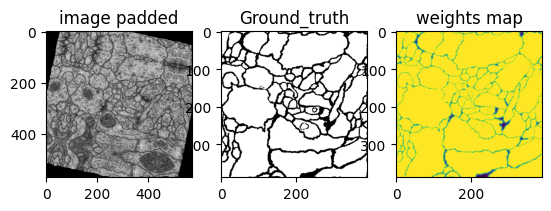

In [6]:
cwd = Path.cwd().parent
path =os.path.join(cwd, "datas/Unet")
shape_orig = 512
shape_in = 572
shape_out = 388

pair_transform = pairTransform(transform)
# pair_transform = None
train_dataset = UnetDataset(path,split='train',transform=pair_transform,padding=92,resized_shape=[shape_out,shape_out])
test_dataset = UnetDataset(path,split='test',transform=pair_transform,padding=92,resized_shape=[shape_out,shape_out])
BATCH_SIZE = 1

train_loader = DataLoader(train_dataset,BATCH_SIZE, True, num_workers=dl_workers)
test_loader = DataLoader(test_dataset,BATCH_SIZE, True, num_workers=dl_workers)
plt.figure()
for images, masks,weights in train_loader:
    print(images.shape)
    print(masks.shape)
    print(weights.shape)
    plt.subplot(1,3,1) 
    plt.imshow(images[0,0], cmap="gray")
    plt.title("image padded")
    plt.subplot(1,3,2)
    plt.imshow(masks[0], cmap="gray")
    plt.title("Ground_truth")
    plt.subplot(1,3,3)
    plt.imshow(weights[0,0])
    plt.title("weights map")
    break
plt.show()

In [7]:
import sys
project_root = str(cwd)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from models.baseline_Unet import U_net

encode_in = (1, 64, 128, 256)
encode_out = (64, 128, 256, 512)
decode_in = (1024, 512, 256, 128)
decode_out = (512, 256, 128, 64)

def init_weights(m):
    if isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.constant_(m.weight, 1)
        nn.init.constant_(m.bias, 0)

model = U_net(encode_in, encode_out, decode_in, decode_out, filter_size=3,upsampling = "Ctranspose",normalize = True)
model.apply(init_weights)
model.to(device)

# test (move input to the same device as the model if needed)
for img, _,_ in train_loader:
    img = img.to(device)
    out = model(img)

Size: torch.Size([1, 1, 572, 572])
Size: torch.Size([1, 64, 570, 570])
Size: torch.Size([1, 64, 568, 568])
Size: torch.Size([1, 64, 284, 284])
Size: torch.Size([1, 128, 282, 282])
Size: torch.Size([1, 128, 280, 280])
Size: torch.Size([1, 128, 140, 140])
Size: torch.Size([1, 256, 138, 138])
Size: torch.Size([1, 256, 136, 136])
Size: torch.Size([1, 256, 68, 68])
Size: torch.Size([1, 512, 66, 66])
Size: torch.Size([1, 512, 64, 64])
Size: torch.Size([1, 1024, 56, 56])
Size: torch.Size([1, 512, 56, 56])
Size: torch.Size([1, 1024, 56, 56])
Size: torch.Size([1, 1024, 56, 56])
Size: torch.Size([1, 512, 54, 54])
Size: torch.Size([1, 512, 52, 52])
Size: torch.Size([1, 512, 104, 104])
Size: torch.Size([1, 256, 104, 104])
Size: torch.Size([1, 512, 104, 104])
Size: torch.Size([1, 512, 104, 104])
Size: torch.Size([1, 256, 102, 102])
Size: torch.Size([1, 256, 100, 100])
Size: torch.Size([1, 256, 200, 200])
Size: torch.Size([1, 128, 200, 200])
Size: torch.Size([1, 256, 200, 200])
Size: torch.Size([1, 

In [8]:
class WeightedCrossEntropyLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.softmax = nn.Softmax(dim=1)      
    def forward(self, logits, targets, weights):
        probs = self.softmax(logits)  
        log_probs = torch.log(probs + 1e-10)  
        loss = -weights.unsqueeze(1) * log_probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        return loss.mean()

loss_fn = WeightedCrossEntropyLoss()
# loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(),lr=0.001,momentum=0.99)
nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma = 0.5)

Logits mean: 0.5590, Probs class 0 mean: 0.3865, Probs class 1 mean: 0.6135


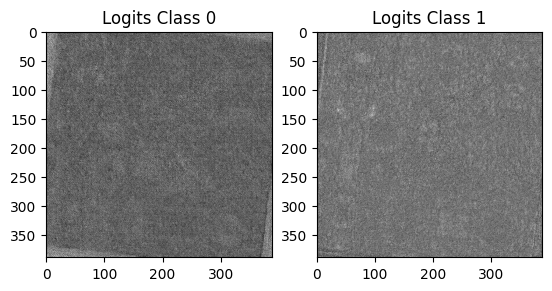

In [ ]:

#Training
model.train()
num_epoch =10 
train_loss= []
for epoch in range(num_epoch):
    step = 0
    epoch_losses = []
    for images,labels,weights in train_loader:
        images,labels,weights = images.to(device) , labels.to(device), weights.to(device)
        optimizer.zero_grad()
        out = model(images)

        # #crop for matching shape
        # out_h,out_w = out.shape[2:]
        # label_h,label_w = labels.shape[1:]
        # crop_h = (label_h-out_h)//2 
        # crop_w = (label_w-out_w)//2
        # labels_cropped = labels[:,crop_h:out_h+crop_h,crop_w:out_w+crop_w]
        # weights_cropped = weights[:,crop_h:out_h+crop_h,crop_w:out_w+crop_w]
        # loss = loss_fn(out,labels_cropped,weights_cropped)
        
        #Debug prediction being all black
        if step == 1:
            probs = torch.softmax(out, dim=1)
            print(f"Logits mean: {out.mean().item():.4f}, Probs class 0 mean: {probs[:, 0].mean().item():.4f}, Probs class 1 mean: {probs[:, 1].mean().item():.4f}")
            plt.figure()
            plt.subplot(1,2,1)
            plt.imshow(out[0, 0].cpu().detach().numpy(), cmap='gray')
            plt.title('Logits Class 0')
            plt.subplot(1,2,2)
            plt.imshow(out[0, 1].cpu().detach().numpy(), cmap='gray')
            plt.title('Logits Class 1')
            plt.show()

        loss = loss_fn(out,labels,weights)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_losses.append(loss.item())
        step +=1
    scheduler.step()

    avg_epoch_loss = np.mean(epoch_losses)
    train_loss.append(avg_epoch_loss)
    print(f"Epoch {epoch+1}/{num_epoch}, Loss: {avg_epoch_loss:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epoch + 1), train_loss, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Evolution')
plt.legend()
plt.grid(True)
plt.show()
        

        

In [ ]:
model.eval()
test_loss = []
metric1 = []

with torch.no_grad():
    for images,labels, weights in test_loader:
        images,labels, weights = images.to(device),labels.to(device) ,weights.to(device)
        out = model(images)

        # #crop
        # out_h,out_w = out.shape[2:]
        # labels_h,labels_w = labels.shape[1:]
        # crop_h = (labels_h - out_h) //2
        # crop_w = (labels_w - out_w) //2
        # labels_cropped = labels[:,crop_h:crop_h+out_h,crop_w:crop_w+out_w]
        # weights_cropped = weights[:,crop_h:crop_h+out_h,crop_w:crop_w+out_w]
        # loss = loss_fn(out,labels_cropped,weights_cropped)
        loss = loss_fn(out,labels,weights)
        test_loss.append(loss.item())

        prediction = torch.argmax(out,dim=1)
        dice = (2 * (prediction & labels).sum())/(prediction.sum() + labels.sum() + 1e-10)
        metric1.append(dice.item())
avg_test_loss = np.mean(test_loss)
avg_dice = np.mean(metric1)
print(f"test loss:{avg_test_loss:.4f}, Dice: {avg_dice:.4f}" )


test loss:0.6215, Dice: 0.8256


torch.Size([1, 2, 388, 388])
torch.Size([1, 388, 388])
[[-0.58461607 -0.7818786  -0.5648301  ... -0.8213307  -0.5480316
  -0.8793827 ]
 [-0.61811864 -0.8045255  -0.5712984  ... -0.8648808  -0.6189227
  -0.9237505 ]
 [-0.5850793  -0.8585641  -0.58001304 ... -0.81292576 -0.5785784
  -0.8836946 ]
 ...
 [-0.61811864 -0.8059962  -0.5843446  ... -0.8138064  -0.5800958
  -0.84050566]
 [-0.5818985  -0.7976171  -0.59157616 ... -0.8704703  -0.5849407
  -0.9388486 ]
 [-0.6158368  -0.7658094  -0.6013062  ... -0.85526156 -0.5954785
  -0.83120024]]


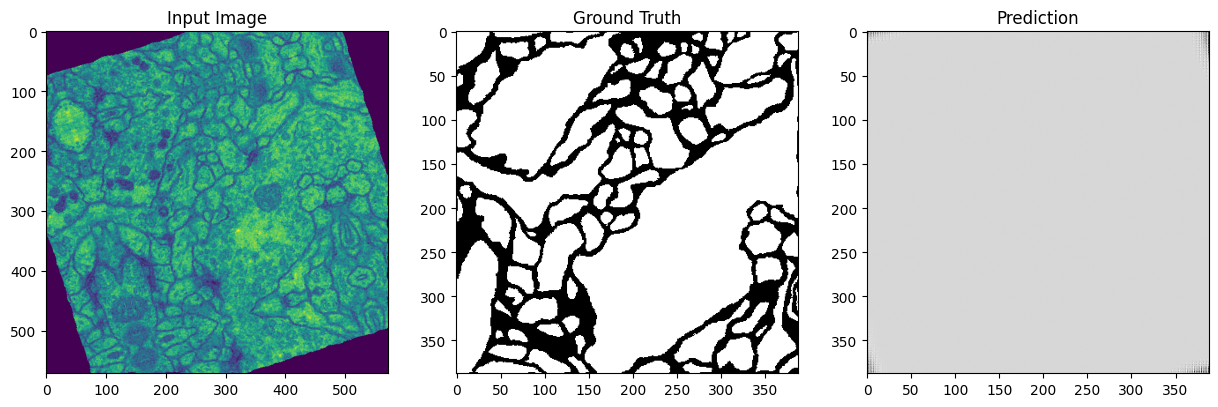

In [ ]:
model.eval()
with torch.no_grad():
    for images, labels, _ in test_loader:
        images = images.to(device)
        out = model(images)
        print(out.shape)
        preds = torch.argmax(out, dim=1).cpu()
        images = images.cpu()
        labels = labels.cpu()
        print(preds.shape) 
        # Plot first sample
        fig, ax = plt.subplots(1, 3, figsize=(15, 5))
        ax[0].imshow(images[0].permute(1, 2, 0).numpy())
        ax[0].set_title('Input Image')
        ax[1].imshow(labels[0].numpy(), cmap='gray')
        ax[1].set_title('Ground Truth')
        ax[2].imshow(out[0,0,:].cpu().numpy(), cmap='gray')
        print(out[0,0,:].cpu().numpy())
        ax[2].set_title('Prediction')
        plt.show()
        break
          # Show one sample


In [ ]:
torch.save(model.state_dict(), 'unet_model_1.pth')
